In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from sklearn.neighbors import KNeighborsClassifier
from termcolor import colored

sns.set_style("darkgrid")
plt.rcParams.update({'font.size': 18})

# Estimating the generalization ability of the trained PyKAN on the valid/test set

In [2]:
loadings = pd.read_csv('loadings.csv').values
train_x = pd.read_csv('../dataset/0-original/X.csv').drop('id', axis=1)
train_y = pd.read_csv('../dataset/0-original/y.csv')['faulty'].values

train_mean, train_std = train_x.mean(), train_x.std()
train_x = (train_x - train_mean) / train_std
train_x = train_x.values.dot(loadings)

valid_x = pd.read_csv('../dataset/0-original/X_validation.csv').drop('id', axis=1)
valid_x = (valid_x - train_mean) / train_std
test_x = pd.read_csv('../dataset/0-original/X_test.csv').drop('id', axis=1)
test_x = (test_x - train_mean) / train_std
valid_test_x = pd.concat([valid_x, test_x], ignore_index=True)
valid_test_x = valid_test_x.values.dot(loadings)
valid_test_y_kan = pd.read_csv('valid_test_y.csv')['faulty']

## Train KNN on the train set and compare the prediction over the valid/test set with the predictions of the PyKAN

In [3]:
k = 300
knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
knn.fit(train_x, train_y)
valid_test_y_knn = pd.Series(knn.predict_proba(valid_test_x)[:, 1])

In [4]:
kan_certainty = valid_test_y_kan[valid_test_y_kan < 0.5].mean(), valid_test_y_kan[valid_test_y_kan >= 0.5].mean()
kan_certainty_train = train_y[train_y < 0.5].mean(), train_y[train_y >= 0.5].mean()
knn_certainty = valid_test_y_knn[valid_test_y_knn < 0.5].mean(), valid_test_y_knn[valid_test_y_knn >= 0.5].mean()
alignment = 1 - np.mean(np.abs(valid_test_y_kan - valid_test_y_knn))
print(f'The alignment score between PyKAN and {k}-NN is -->', colored(f'{alignment:.3f}', 'green', attrs=['bold']))

The alignment score between PyKAN and 300-NN is --> 0.576


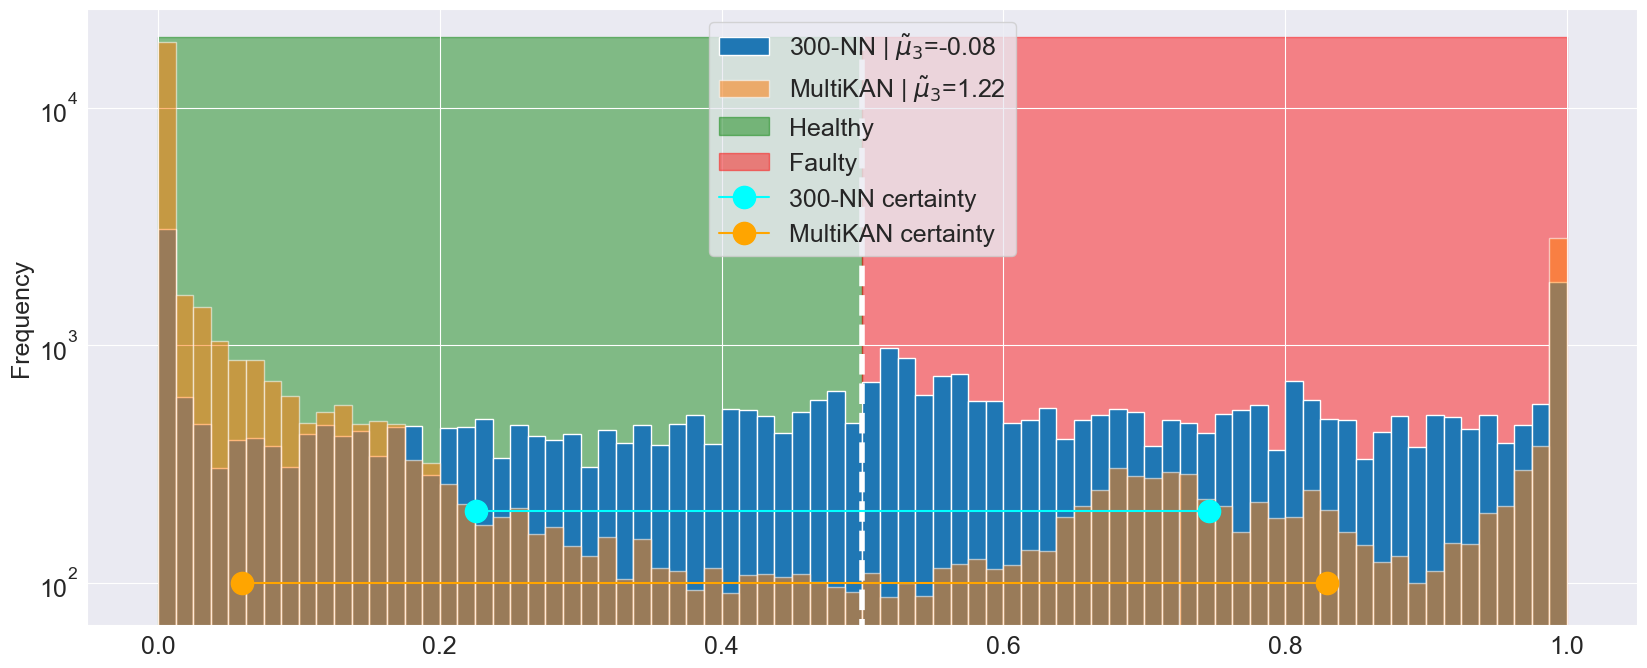

In [254]:
ax = valid_test_y_knn.plot(kind='hist', bins=80, figsize=(20, 8),
                           label=f'{k}-NN | $\\tilde{"{"}\\mu{"}"}_3$={valid_test_y_knn.skew():.2f}')
valid_test_y_kan.plot(kind='hist', bins=80, alpha=0.55, ax=ax,
                      label=f'MultiKAN | $\\tilde{"{"}\\mu{"}"}_3$={valid_test_y_kan.skew():.2f}')
height = ax.get_ylim()[1]
ax.add_line(Line2D([0.5, 0.5], [0, height], linestyle='--', color='w', linewidth=4))
ax.fill_between([0, 0.5], height, alpha=0.45, color='g', zorder=0, label='Healthy')
ax.fill_between([0.5, 1], height, alpha=0.45, color='r', zorder=0, label='Faulty')
ax.plot([knn_certainty[0], knn_certainty[1]], [200] * 2, c='cyan', marker='o', markersize=16, label=f'{k}-NN certainty')
ax.plot([kan_certainty[0], kan_certainty[1]], [100] * 2, 'orange', marker='o', markersize=16,
        label=f'MultiKAN certainty')
ax.plot([kan_certainty_train[0], kan_certainty_train[1]], [100] * 2, 'orange', marker='o', markersize=16,
        label=f'MultiKAN certainty')

ax.legend(loc='upper center')
ax.set_yscale('log')
plt.show()

# Plot K-NN prediction

In [239]:
def plot_3d_pca(data, labels, scale=0.5, ax=None, c=None, alpha=0.04, azim=180 + 55,
                only_faulty=False, ):
    if ax is None:
        fig = plt.figure(figsize=(20 * scale, 20 * scale))
        ax = fig.add_subplot(111, projection='3d')
        ax.view_init(elev=25, azim=azim)
        plt.legend(loc="upper right")
        plt.grid(True)

    if c is None:
        c = {0: 'g', 1: 'r'}
    s = 0.5 * 750_000 / len(data)
    for label in [0, 1] if not only_faulty else [1]:
        ax.scatter(
            data[labels == label][:, 0],
            data[labels == label][:, 1],
            data[labels == label][:, 2],
            c=c[label],
            label={0: 'Healthy', 1: 'Faulty'}[label], alpha=alpha, s=s
        )
    return ax

C:\Users\MrPio\AppData\Local\Temp\ipykernel_7304\3512796302.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


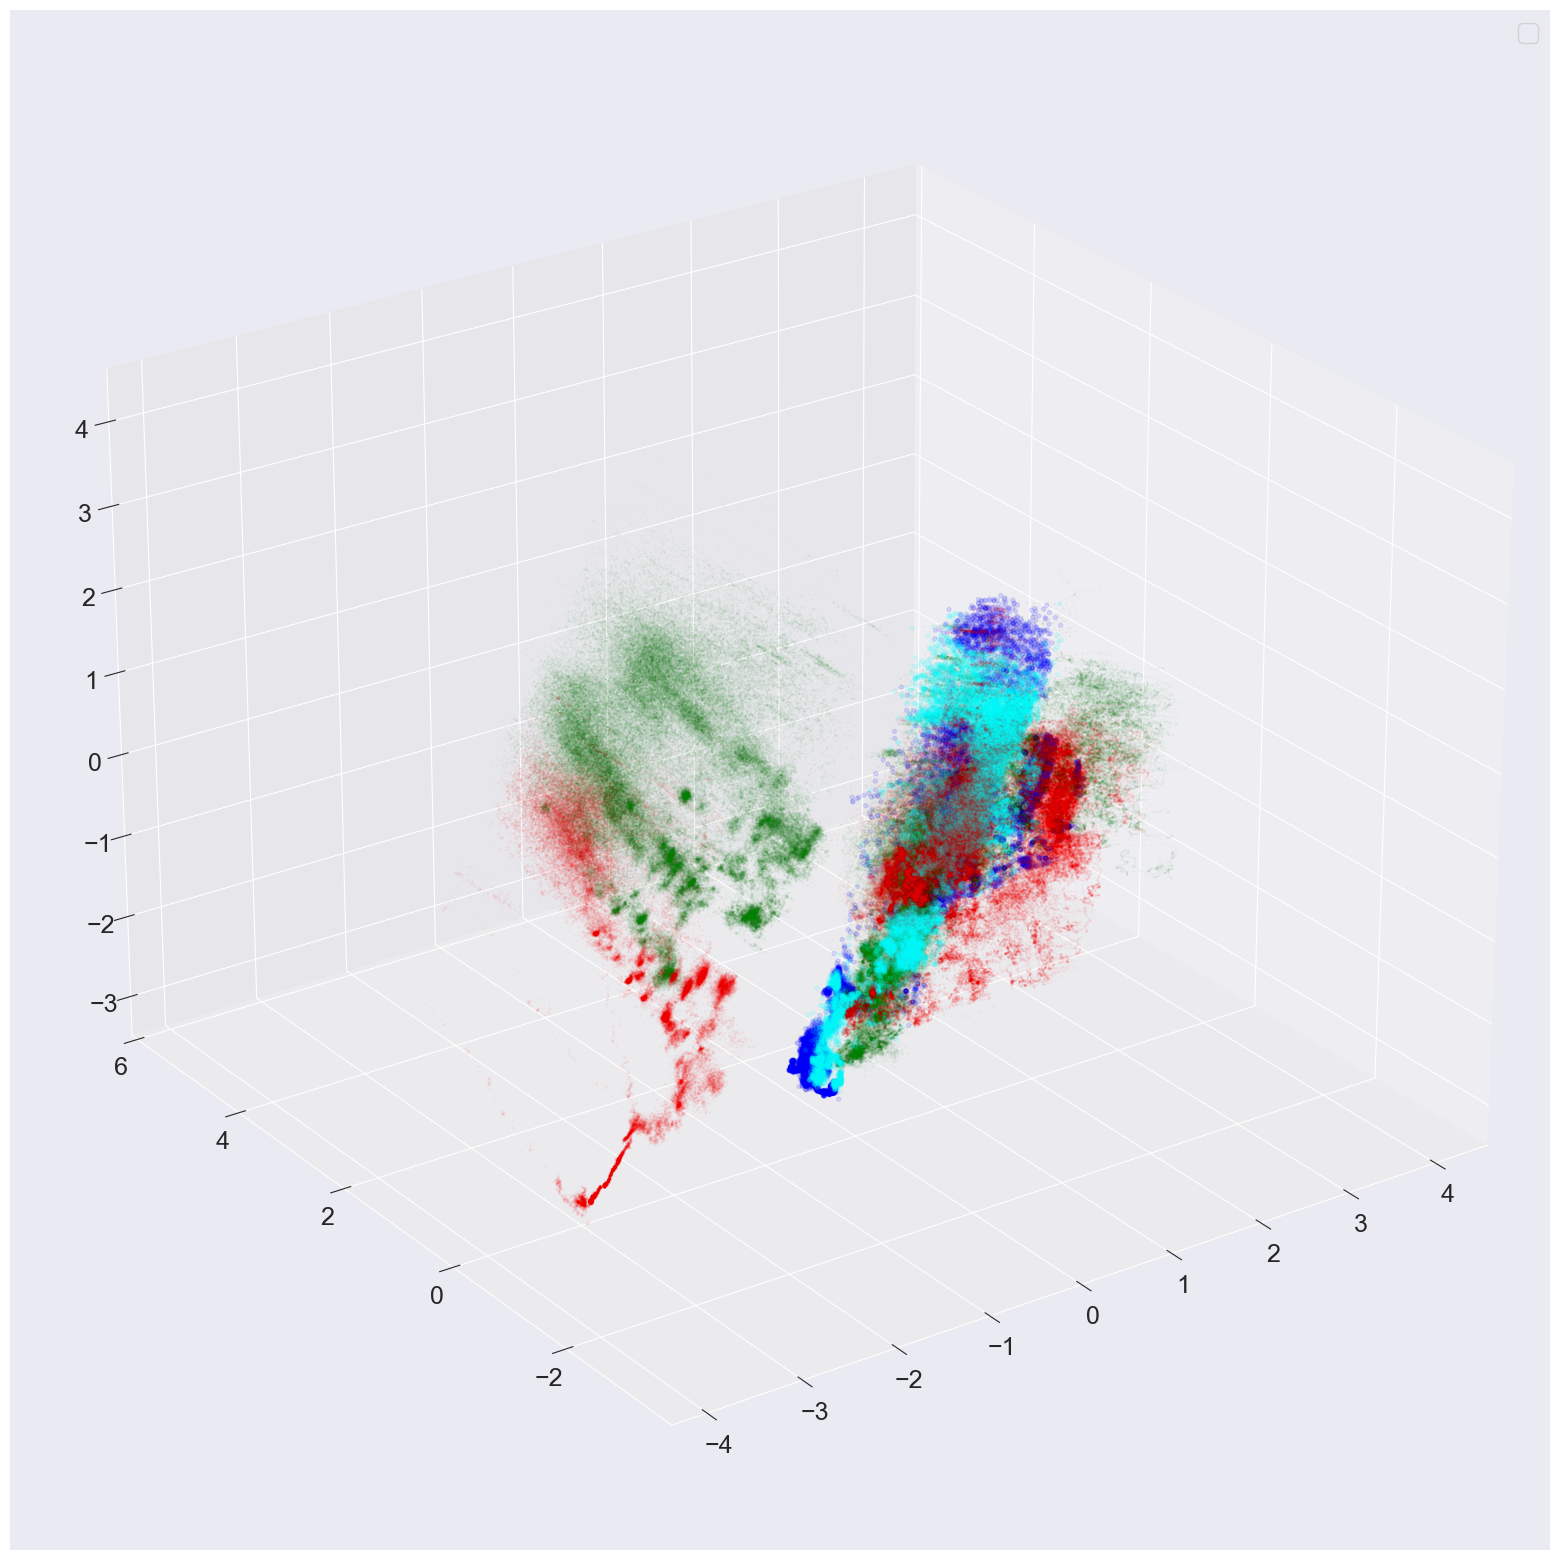

In [242]:
ax = plot_3d_pca(train_x, train_y, scale=1, alpha=0.025)
plot_3d_pca(valid_test_x, valid_test_y_knn > 0.5, c={0: 'cyan', 1: 'blue'}, ax=ax, alpha=0.1)
plt.show()